# OSMnx Analyses with `smolagents`

This notebook demonstrates how to integrate **OSMnx-based spatial network analysis** with **LLM agents** using the **smolagents** framework, .

The goal is to expose common spatial analysis workflows as **callable tools** that an AI agent can invoke dynamically when answering user questions.

Through this integration, an agent can:

- retrieve geographic data from **OpenStreetMap**
- construct and analyze **street networks**
- compute spatial metrics
- visualize results

This notebook illustrates how spatial analysis pipelines can be turned into **AI-accessible tools**, enabling agents to reason about and interact with geographic data.

## Step 0: Install dependencies (run once)

First install the required Python packages.

We use:

- **OSMnx** for downloading and analyzing street networks from OpenStreetMap
- **smolagents** for building lightweight tool-using LLM agents
- **geopandas**, **networkx**, and related geospatial libraries for spatial data processing

Run the following cell to install dependencies.

In [1]:

%pip install -q osmnx geopandas networkx matplotlib smolagents

Note: you may need to restart the kernel to use updated packages.


## Step 1: Set Up Hugging Face API Token and Initialize the Agent

The agent uses a powerful language model from the Hugging Face Hub. To access it, you need an API token.

1.  If you don't have one, create a free Hugging Face account and get a token from your [**profile settings**](https://huggingface.co/settings/tokens) (Create new token -> give "write" permission).
2.  Run the cell below. A text field will appear.
3.  Paste your token into the field and press Enter. The token will be hidden for security.

This will load the token and initialize the agent's brain (the language model).

Please be aware that the free credit for trying out the LLMs on Hugging Face is limited. You can also use your own LLM API.


In [1]:
import os
import getpass
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple, Union

import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

from smolagents import CodeAgent, tool
from smolagents.models import InferenceClientModel

ox.settings.use_cache = True
ox.settings.log_console = True
print('OSMnx version:', ox.__version__)

if not os.getenv('HF_TOKEN'):
    hf_token = getpass.getpass('Please enter your Hugging Face API token: ')
    os.environ['HF_TOKEN'] = hf_token

if not os.getenv('HF_TOKEN'):
    raise ValueError('HF_TOKEN is required.')


@dataclass
class OSMnxAgentState:
    graphs: Dict[str, nx.MultiDiGraph] = field(default_factory=dict)
    nodes: Dict[str, int] = field(default_factory=dict)
    geocodes: Dict[str, Tuple[float, float]] = field(default_factory=dict)
    routes: Dict[str, List[int]] = field(default_factory=dict)
    projected_graphs: Dict[str, nx.MultiDiGraph] = field(default_factory=dict)
    isochrones: Dict[str, List[Tuple[int, Any]]] = field(default_factory=dict)
    pois: Dict[str, gpd.GeoDataFrame] = field(default_factory=dict)
    stats: Dict[str, Dict[str, Any]] = field(default_factory=dict)

state = OSMnxAgentState()

model = InferenceClientModel(
    model_id='Qwen/Qwen2.5-72B-Instruct',
    token=os.environ['HF_TOKEN'],
)


def build_agent(tools: List[Any], max_steps: int = 14) -> CodeAgent:
    return CodeAgent(tools=tools, model=model, add_base_tools=False, max_steps=max_steps)

print('Base setup complete.')

OSMnx version: 2.1.0


Please enter your Hugging Face API token:  ········


Base setup complete.


## Defining the Tools

Instead of implementing the spatial analysis as a single monolithic script, we expose key functionalities as **modular tools** that can be invoked by an AI agent.

Each tool performs a well-defined task, for example:

- retrieving a street network  
- computing centrality metrics  
- visualizing a graph  
- extracting spatial statistics  

By structuring the workflow in this way, the agent can **select and execute the appropriate tools** based on the user’s query. This design provides several advantages:

- **Modularity and reusability** of spatial analysis components  
- **Transparent and interpretable reasoning steps** during agent execution  
- **Flexible, dynamically generated workflows** tailored to user requests  

In the following sections, we wrap several workflows from the original **OSMnx notebook** as agent tools. The analyses themselves—and the corresponding API calls—are relatively straightforward in the original notebook. However, our goal here is to demonstrate how existing functions or workflows can be **encapsulated as AI-ready tools** and exposed for use by an AI agent.

We hope this example provides a simple template for defining your own analytical functions as tools that can be **discovered, invoked, and orchestrated by an AI agent**.

## Case 1: Routing Basics


In [2]:
@tool
def load_network(place: Union[str, List[str]], network_type: str, graph_key: str = '') -> str:
    """Load an OSMnx network for a place and store it in state.

    Args:
        place: Place string or list of place strings.
        network_type: 'drive' or 'walk'.
        graph_key: Optional key to store graph.
    """
    nt = network_type.lower().strip()
    if nt not in {'drive', 'walk'}:
        raise ValueError("network_type must be 'drive' or 'walk'")

    if isinstance(place, list):
        key_base = '_'.join(p.lower().replace(',', '').replace(' ', '_') for p in place)
    else:
        key_base = place.lower().replace(',', '').replace(' ', '_')

    key = graph_key.strip() or f"{key_base}__{nt}"
    G = ox.graph_from_place(place, network_type=nt)
    state.graphs[key] = G
    return f"Loaded graph '{key}' with {len(G.nodes)} nodes and {len(G.edges)} edges."


@tool
def geocode_location(location: str, geocode_key: str = '') -> str:
    """Geocode a location string and store (lat, lon).

    Args:
        location: Place or address string.
        geocode_key: Optional key to store geocoded coordinate.
    """
    lat, lon = ox.geocode(location)
    key = geocode_key.strip() or location.lower().replace(',', '').replace(' ', '_')
    state.geocodes[key] = (float(lat), float(lon))
    return f"Stored geocode '{key}' = (lat={lat:.6f}, lon={lon:.6f})."


@tool
def nearest_node_from_location(graph_key: str, location: str, node_key: str = '') -> str:
    """Find nearest node in a graph to a geocoded location string.

    Args:
        graph_key: Key of a loaded graph.
        location: Location string to geocode.
        node_key: Optional key to store node id.
    """
    if graph_key not in state.graphs:
        raise KeyError(f"Unknown graph_key: {graph_key}")

    G = state.graphs[graph_key]
    lat, lon = ox.geocode(location)
    node_id = int(ox.distance.nearest_nodes(G, X=lon, Y=lat))

    key = node_key.strip() or f"{location.lower().replace(',', '').replace(' ', '_')}__node"
    state.nodes[key] = node_id
    return f"Stored node '{key}' = {node_id}."


@tool
def shortest_path(graph_key: str, origin_node_key: str, destination_node_key: str, weight: str = 'length', route_key: str = '') -> str:
    """Compute a shortest path on a graph and store route.

    Args:
        graph_key: Key of a loaded graph.
        origin_node_key: Key of stored origin node id.
        destination_node_key: Key of stored destination node id.
        weight: Edge weight ('length' or 'travel_time').
        route_key: Optional key to store route.
    """
    if graph_key not in state.graphs:
        raise KeyError(f"Unknown graph_key: {graph_key}")
    if origin_node_key not in state.nodes or destination_node_key not in state.nodes:
        raise KeyError('origin_node_key or destination_node_key not found')

    G = state.graphs[graph_key]
    origin = state.nodes[origin_node_key]
    dest = state.nodes[destination_node_key]

    route = ox.shortest_path(G, origin, dest, weight=weight)
    if not route:
        raise ValueError('No route found')

    key = route_key.strip() or f"{origin_node_key}_to_{destination_node_key}__{weight}"
    state.routes[key] = route

    length_m = 0.0
    travel_sec = 0.0
    for u, v in zip(route[:-1], route[1:]):
        edge_data = min(G.get_edge_data(u, v).values(), key=lambda d: d.get(weight, float('inf')))
        length_m += float(edge_data.get('length', 0.0))
        travel_sec += float(edge_data.get('travel_time', 0.0))

    return (
        f"Stored route '{key}' with {len(route)} nodes. "
        f"Length={length_m:.1f} m. TravelTime={travel_sec/60:.1f} min (if available)."
    )


@tool
def visualize_route(graph_key: str, route_key: str, bbox: Optional[Tuple[float, float, float, float]] = None) -> Any:
    """Plot a stored route on a graph and return matplotlib figure.

    Args:
        graph_key: Key of a loaded graph.
        route_key: Key of a stored route.
        bbox: Optional (north, south, east, west) to zoom.
    """
    if graph_key not in state.graphs:
        raise KeyError(f"Unknown graph_key: {graph_key}")
    if route_key not in state.routes:
        raise KeyError(f"Unknown route_key: {route_key}")

    fig, ax = ox.plot_graph_route(
        state.graphs[graph_key],
        state.routes[route_key],
        route_linewidth=3,
        node_size=0,
        bgcolor='white',
        bbox=bbox,
        show=False,
        close=False,
    )
    return fig


tools_case1 = [
    load_network, geocode_location, nearest_node_from_location, shortest_path, visualize_route
]
agent_case1 = build_agent(tools_case1)
print('Case 1 tools ready.')

Case 1 tools ready.


### Case 1 Demo Query
#### **Note: The agent will work better if more detailed instructions is given. However, let's try some simple natural language query to see how smart the agent is.**

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Visualize the shortest path between the 'Hilton San Francisco Union Square, San Francisco, California, USA' and │
│ 'Golden Gate Park, San Francisco, California, USA' on the walk network.                                         │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-72B-Instruct ──────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  load_network(place='San Francisco, California, USA', network_type='walk', graph_key='san_francisco_walk')        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out: Loaded graph 'san_francisco_walk' with 51013 nodes and 153496 edges.

[Step 1: Duration 58.77 seconds| Input tokens: 2,367 | Output tokens: 133]

...

[Step 4: Duration 6.05 seconds| Input tokens: 10,938 | Output tokens: 597]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 5 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  fig = visualize_route(graph_key='san_francisco_walk', route_key='shortest_path_route', bbox=None)                
  final_answer(fig)                                                                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Figure(800x800)

[Step 5: Duration 12.30 seconds| Input tokens: 14,259 | Output tokens: 664]

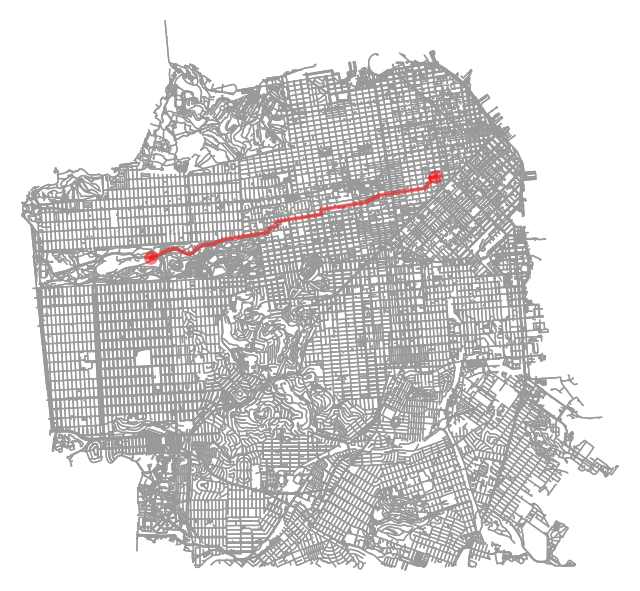

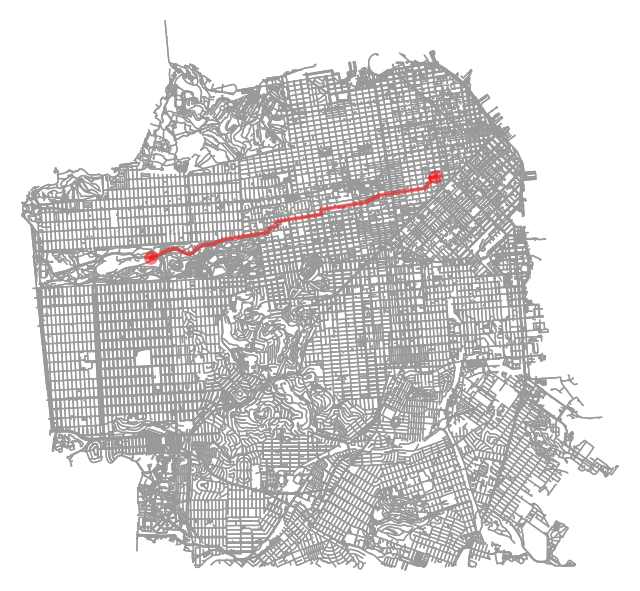

In [3]:
query_case1 = """
Visualize the shortest path between the 'Hilton San Francisco Union Square, San Francisco, California, USA' and 'Golden Gate Park, San Francisco, California, USA' on the walk network.
"""
agent_case1.run(query_case1)

## Case 2: Shortest Time vs. Shortest Distance

In [6]:
@tool
def add_travel_times_to_graph(graph_key: str) -> str:
    """Add speed_kph and travel_time to graph edges.

    Args:
        graph_key: Key of a loaded graph.
    """
    if graph_key not in state.graphs:
        raise KeyError(f"Unknown graph_key: {graph_key}")
    G = state.graphs[graph_key]
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)
    state.graphs[graph_key] = G

    edge = list(G.edges(data=True))[0][2]
    return (
        f"Updated '{graph_key}' with speed_kph and travel_time. "
        f"Sample edge length={edge.get('length')}, speed_kph={edge.get('speed_kph')}, travel_time={edge.get('travel_time')}"
    )


@tool
def compare_two_routes(graph_key: str, route_key_a: str, route_key_b: str, color_a: str = 'red', color_b: str = 'blue') -> Any:
    """Plot two stored routes on the same graph.

    Args:
        graph_key: Key of loaded graph.
        route_key_a: First route key.
        route_key_b: Second route key.
        color_a: Color for first route.
        color_b: Color for second route.
    """
    if graph_key not in state.graphs:
        raise KeyError(f"Unknown graph_key: {graph_key}")
    if route_key_a not in state.routes or route_key_b not in state.routes:
        raise KeyError('route key missing')

    fig, ax = ox.plot_graph_routes(
        state.graphs[graph_key],
        routes=[state.routes[route_key_a], state.routes[route_key_b]],
        route_colors=[color_a, color_b],
        route_linewidth=2,
        node_size=0,
        bgcolor='white',
        show=False,
        close=False,
    )
    return fig


tools_case2 = tools_case1 + [add_travel_times_to_graph, compare_two_routes]
agent_case2 = build_agent(tools_case2)
print('Case 2 tools ready.')

Case 2 tools ready.


### Case 2 demo query
The whole tool set will be used to answer the query.

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Compute shortest path by length and travel_time between 'Hilton San Francisco Union Square, San Francisco,      │
│ California, USA' and 'Golden Gate Park, San Francisco, California, USA'.                                        │
│ Compare both routes on one map.                                                                                 │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-72B-Instruct ──────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  load_network(place="San Francisco, California, USA", network_type="drive", graph_key="sf_graph")                 
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out: Loaded graph 'sf_graph' with 10040 nodes and 27650 edges.

[Step 1: Duration 22.41 seconds| Input tokens: 2,508 | Output tokens: 66]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 5 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("The shortest path by length and travel time between 'Hilton San Francisco Union Square, San        
  Francisco, California, USA' and 'Golden Gate Park, San Francisco, California, USA' have been computed and        
  compared on one map. The blue route represents the shortest path by length, while the red route represents the   
  shortest path by travel time.")                                                                                  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: The shortest path by length and travel time between 'Hilton San Francisco Union Square, San 
Francisco, California, USA' and 'Golden Gate Park, San Francisco, California, USA' have been computed and compared 
on one map. The blue route represents the shortest path by length, while the red route represents the shortest path
by travel time.

[Step 5: Duration 6.86 seconds| Input tokens: 15,119 | Output tokens: 733]

"The shortest path by length and travel time between 'Hilton San Francisco Union Square, San Francisco, California, USA' and 'Golden Gate Park, San Francisco, California, USA' have been computed and compared on one map. The blue route represents the shortest path by length, while the red route represents the shortest path by travel time."

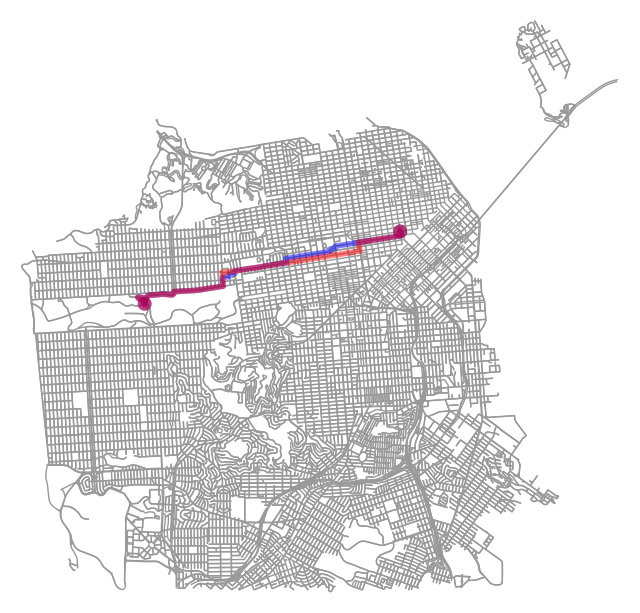

In [5]:
query_case2 = """
Compute shortest path by length and travel_time between 'Hilton San Francisco Union Square, San Francisco, California, USA' and 'Golden Gate Park, San Francisco, California, USA'.
Compare both routes on one map.
"""
agent_case2.run(query_case2)

## Case 3: Isochrone Computation

In [7]:
@tool
def build_isochrones(graph_key: str, center_node_key: str, trip_minutes: List[int], projected_graph_key: str = '', isochrone_key: str = '') -> str:
    """Build travel-time isochrones from a center node.

    Args:
        graph_key: Key of loaded graph (should include travel_time on edges).
        center_node_key: Stored center node key.
        trip_minutes: Time thresholds in minutes, e.g. [5, 10].
        projected_graph_key: Optional key to store projected graph.
        isochrone_key: Optional key to store generated polygons.
    """
    if graph_key not in state.graphs:
        raise KeyError(f"Unknown graph_key: {graph_key}")
    if center_node_key not in state.nodes:
        raise KeyError(f"Unknown center_node_key: {center_node_key}")

    G = state.graphs[graph_key]
    center_node = state.nodes[center_node_key]

    G_proj = ox.project_graph(G)
    pkey = projected_graph_key.strip() or f"{graph_key}__projected"
    state.projected_graphs[pkey] = G_proj

    trip_times = [int(m) * 60 for m in sorted(trip_minutes)]
    travel_time = nx.single_source_dijkstra_path_length(G_proj, center_node, weight='travel_time')

    iso_polys: List[Tuple[int, Any]] = []
    for tt in trip_times:
        subnodes = [n for n, t in travel_time.items() if t <= tt]
        subgraph = G_proj.subgraph(subnodes)
        _, subedges = ox.graph_to_gdfs(subgraph)
        if len(subedges) == 0:
            continue
        merged = subedges.buffer(80).unary_union
        iso_polys.append((tt, merged))

    ikey = isochrone_key.strip() or f"{graph_key}__isochrones"
    state.isochrones[ikey] = iso_polys
    return f"Stored {len(iso_polys)} isochrone polygons as '{ikey}' (projected graph key '{pkey}')."


@tool
def visualize_isochrones(projected_graph_key: str, center_node_key: str, isochrone_key: str) -> Any:
    """Plot projected edges with isochrone polygons and center node.

    Args:
        projected_graph_key: Key of stored projected graph.
        center_node_key: Key of stored center node id.
        isochrone_key: Key of stored isochrone polygons.
    """
    if projected_graph_key not in state.projected_graphs:
        raise KeyError(f"Unknown projected_graph_key: {projected_graph_key}")
    if center_node_key not in state.nodes:
        raise KeyError(f"Unknown center_node_key: {center_node_key}")
    if isochrone_key not in state.isochrones:
        raise KeyError(f"Unknown isochrone_key: {isochrone_key}")

    G_proj = state.projected_graphs[projected_graph_key]
    center_node = state.nodes[center_node_key]
    nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_proj)

    fig, ax = plt.subplots(figsize=(8, 8))
    edges_gdf.plot(ax=ax, linewidth=0.5, alpha=0.4, color='gray')

    palette = ['#fb6a4a', '#fee5d9', '#fcbba1', '#fc9272']
    for idx, (tt, poly) in enumerate(state.isochrones[isochrone_key]):
        gpd.GeoSeries([poly]).plot(
            ax=ax,
            facecolor=palette[idx % len(palette)],
            edgecolor='none',
            alpha=0.7,
            label=f"{tt/60:.0f} min",
        )

    center_geom = nodes_gdf.loc[center_node].geometry
    gpd.GeoSeries([center_geom]).plot(ax=ax, color='black', markersize=30, label='Center')
    ax.legend()
    ax.set_title('Driving Isochrones')
    plt.tight_layout()
    return fig


tools_case3 = tools_case2 + [build_isochrones, visualize_isochrones]
agent_case3 = build_agent(tools_case3, max_steps=18)
print('Case 3 tools ready.')

Case 3 tools ready.


### Case 3 demo query

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Visualize the driving Isochrones from 'Hilton San Francisco Union Square, San Francisco, California, USA' with  │
│ travel-time thresholds: 5 and 10 minutes in the map of San Francisco, CA, USA.                                  │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-72B-Instruct ──────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  geocode_location(location="Hilton San Francisco Union Square, San Francisco, California, USA",                   
  geocode_key="hotel_location")                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out: Stored geocode 'hotel_location' = (lat=37.785734, lon=-122.410437).

[Step 1: Duration 5.18 seconds| Input tokens: 2,719 | Output tokens: 156]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 7 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("The driving isochrones from Hilton San Francisco Union Square, San Francisco, California, USA,     
  with travel-time thresholds of 5 and 10 minutes have been visualized on the map of San Francisco, CA, USA.")     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: The driving isochrones from Hilton San Francisco Union Square, San Francisco, California, USA, with 
travel-time thresholds of 5 and 10 minutes have been visualized on the map of San Francisco, CA, USA.

[Step 7: Duration 5.59 seconds| Input tokens: 23,387 | Output tokens: 891]

'The driving isochrones from Hilton San Francisco Union Square, San Francisco, California, USA, with travel-time thresholds of 5 and 10 minutes have been visualized on the map of San Francisco, CA, USA.'

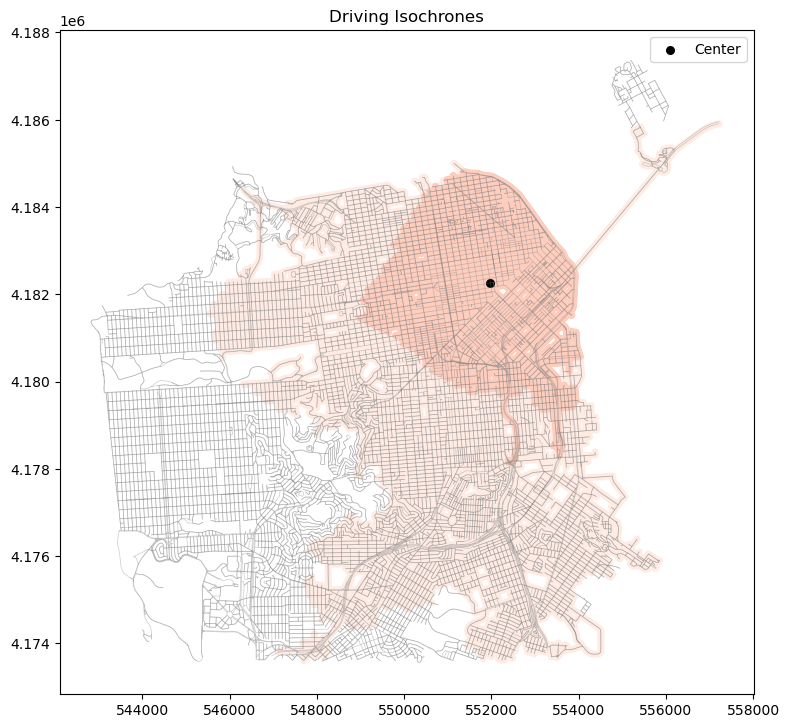

In [8]:
query_case3 = """
Visualize the driving Isochrones from 'Hilton San Francisco Union Square, San Francisco, California, USA' with travel-time thresholds: 5 and 10 minutes in the map of San Francisco, CA, USA.
"""
agent_case3.run(query_case3)

## Case 4:  Nearest Grocery Store

In [ ]:
@tool
def route_to_nearest_poi(graph_key: str, origin_node_key: str, tags: Dict[str, str], route_key: str = '', poi_store_key: str = '') -> str:
    """Find nearest POI to origin node and compute travel-time route.

    Args:
        graph_key: Key of loaded graph.
        origin_node_key: Key of stored origin node id.
        tags: OSM tags dict, e.g. {'shop': 'supermarket'}.
        route_key: Optional route key.
        poi_store_key: Optional key to store POI geodataframe.
    """
    if graph_key not in state.graphs:
        raise KeyError(f"Unknown graph_key: {graph_key}")
    if origin_node_key not in state.nodes:
        raise KeyError(f"Unknown origin_node_key: {origin_node_key}")

    G = state.graphs[graph_key]
    origin_node = state.nodes[origin_node_key]

    # Use graph's place if available; otherwise fall back to CU area used in source notebook.
    place_query: Union[str, List[str]] = ['Champaign, Illinois, USA', 'Urbana, Illinois, USA']
    pois = ox.features_from_place(place_query, tags=tags)
    pois = pois.to_crs(G.graph['crs'])

    nodes_gdf, _ = ox.graph_to_gdfs(G)
    origin_geom = nodes_gdf.loc[origin_node].geometry

    def representative_point(geom):
        return geom if geom.geom_type == 'Point' else geom.centroid

    reps = pois.geometry.apply(representative_point)
    nearest_geom = min(reps, key=lambda p: p.distance(origin_geom))

    dest_node = int(ox.distance.nearest_nodes(G, X=nearest_geom.x, Y=nearest_geom.y))
    route = ox.shortest_path(G, origin_node, dest_node, weight='travel_time')
    if not route:
        raise ValueError('No route found to nearest POI')

    rkey = route_key.strip() or f"{origin_node_key}_to_nearest_poi__travel_time"
    state.routes[rkey] = route

    pkey = poi_store_key.strip() or 'last_poi_query'
    state.pois[pkey] = pois

    return f"Stored route '{rkey}' to nearest POI node {dest_node}. POI set stored as '{pkey}'."


tools_case4 = tools_case3 + [route_to_nearest_poi]
agent_case4 = build_agent(tools_case4, max_steps=20)
print('Case 4 tools ready.')

Case 4 tools ready.


## Optional: Inspect State Keys

The results and intermediate parameters from the workflow are stored in the **state object**. This allows us to inspect the computation process and review intermediate outputs if needed.

This can be useful for **debugging, transparency, and reproducibility**, especially when the agent performs multiple tool calls during a complex analysis.

In [8]:
print('graphs:', list(state.graphs.keys()))
print('nodes:', list(state.nodes.keys()))
print('geocodes:', list(state.geocodes.keys()))
print('routes:', list(state.routes.keys()))
print('projected_graphs:', list(state.projected_graphs.keys()))
print('isochrones:', list(state.isochrones.keys()))
print('pois:', list(state.pois.keys()))
print('stats:', list(state.stats.keys()))

graphs: ['uiuc_walk_network', 'champaign_urbana_network', 'illinois_network']
nodes: ['illini_union_node', 'siebel_center_node', 'node_illini_union', 'node_market_place']
geocodes: ['illini_union', 'siebel_center', 'market_place', 'illini_union_location']
routes: ['shortest_path_route', 'route_length', 'route_travel_time']
projected_graphs: ['projected_illinois_network']
isochrones: ['illini_union_isochrones']
pois: []
stats: []
